In [1]:
from glob import glob
star_name = 'HIP19793'

for filepath in glob(f'tull_spectra_astro9/*/*/*{star_name}*_spectrum.fits'):
    print(filepath)

tull_spectra_astro9\ts23_2022_FEB\2022feb20\n0016_HIP19793_ts23_2022feb20_spectrum.fits
tull_spectra_astro9\ts23_2022_FEB\2022feb20\n0017_HIP19793_ts23_2022feb20_spectrum.fits


Estimated SNR per pixel ≈ 19
Continuum noise σ ≈ 0.0529 (normalised flux)

Best-fit: C1=0.2126, C2=0.1792, σ=0.1238 Å, RVs=-0.4823
Burn-in...


100%|███████████████████████████████████████████████████████████████████████████████| 500/500 [00:01<00:00, 292.32it/s]


Production...


100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:04<00:00, 440.89it/s]



EW = 65.2 ± 11.5 mÅ
Upper limits — 1σ: 70.9 mÅ  2σ: 86.3 mÅ  3σ: 100.4 mÅ


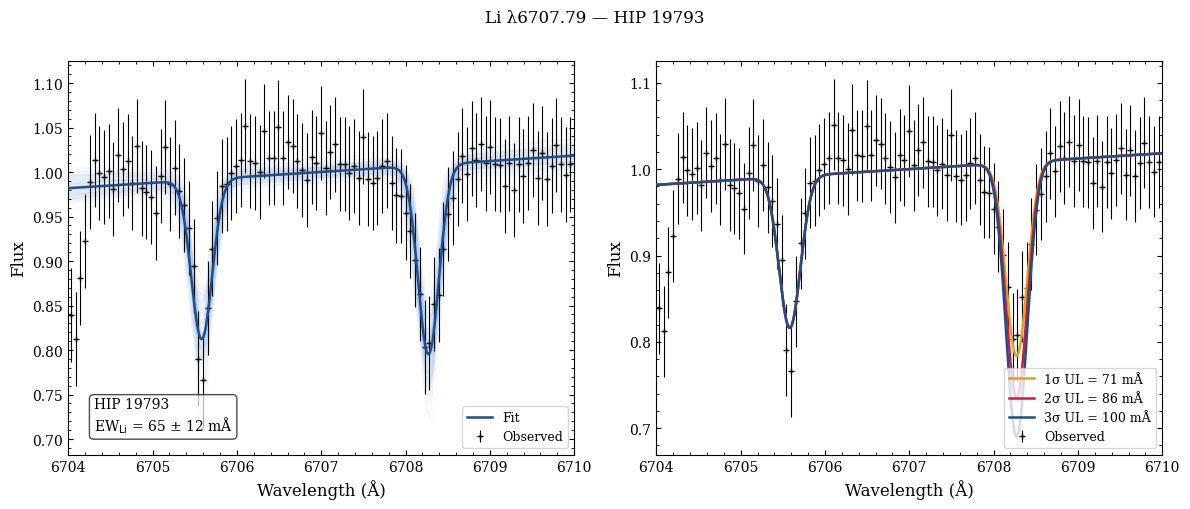

Saved: lithium_figure4_style.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from astropy.io import fits
import emcee
from scipy.optimize import minimize


plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
})

RV_STAR_KMS   = 37.5    # star's radial velocity in km/s (from Gaia DR3)
STAR_NAME     = 'HIP 19793'
 
FLUX_FILE = 'n0017_HIP19793_ts23_2022feb20_spectrum.fits'
WAVE_FILE = 'ts23_2022feb20_thar_solution_wavearr.fits'
 

flux_hdul = fits.open(FLUX_FILE)
wave_hdul = fits.open(WAVE_FILE)
flux_all  = flux_hdul[0].data.astype(float)
wave_all  = wave_hdul[0].data.astype(float)
 
LI_WAVE   = 6707.79
FE_WAVE   = 6705.10
C_KMS     = 2.998e5
 
def get_order(wave_all, flux_all, target=LI_WAVE):
    if wave_all.ndim == 2:
        for i in range(wave_all.shape[0]):
            if wave_all[i].min() < target < wave_all[i].max():
                return wave_all[i], flux_all[i]
        raise ValueError("No order found covering λ6707.79 Å")
    return wave_all, flux_all
 
wave_raw, flux_raw = get_order(wave_all, flux_all)
 
wave_rest = wave_raw / (1.0 + RV_STAR_KMS / C_KMS)
 
mask = (wave_rest >= 6704.0) & (wave_rest <= 6710.0)
w = wave_rest[mask]
f = flux_raw[mask]
 
cont_mask = ((w > 6704.0) & (w < 6704.8)) | ((w > 6709.2) & (w < 6710.0))
continuum = np.median(f[cont_mask]) if cont_mask.sum() > 3 else np.percentile(f, 90)
f_norm = f / continuum
 
noise_std = np.std(f_norm[cont_mask]) if cont_mask.sum() > 3 else 0.01

snr_pixel = 1.0 / noise_std if noise_std > 0 else 50.0
f_err = np.full_like(f_norm, noise_std)   # uniform error bars
 
print(f"Estimated SNR per pixel ≈ {snr_pixel:.0f}")
print(f"Continuum noise σ ≈ {noise_std:.4f} (normalised flux)")
 
def model(lam, m, b, C1, C2, sigma, RVs):
    cont  = m * (lam - 6707.0) + b
    g_li  = C1 * np.exp(-0.5 * ((LI_WAVE  - RVs - lam) / sigma)**2)
    g_ref = C2 * np.exp(-0.5 * ((FE_WAVE  - RVs - lam) / sigma)**2)
    return cont - g_li - g_ref
 
def neg_log_like(theta):
    m, b, C1, C2, sigma, RVs = theta
    if sigma <= 0 or C1 < 0 or C2 < 0:
        return np.inf
    pred  = model(w, *theta)
    chi2  = np.sum(((f_norm - pred) / f_err)**2)
    return 0.5 * chi2
 
def log_prior(theta):
    m, b, C1, C2, sigma, RVs = theta
    if (0 < sigma < 5 and 0 <= C1 < 0.8 and 0 <= C2 < 0.8
            and -0.5 < m < 0.5 and 0.5 < b < 1.5 and -5 < RVs < 5):
        return 0.0
    return -np.inf
 
def log_prob(theta):
    lp = log_prior(theta)
    return lp - neg_log_like(theta) if np.isfinite(lp) else -np.inf
 

p0     = [0.0, 1.0, 0.05, 0.10, 0.5, 0.0]
result = minimize(neg_log_like, p0, method='Nelder-Mead',
                  options={'maxiter': 100000, 'xatol':1e-7, 'fatol':1e-7})
p_best = result.x
print(f"\nBest-fit: C1={p_best[2]:.4f}, C2={p_best[3]:.4f}, σ={p_best[4]:.4f} Å, RVs={p_best[5]:.4f}")
 
# MCMC
ndim, nwalkers = 6, 32
pos = p_best + 1e-4 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
print("Burn-in...")
sampler.run_mcmc(pos, 500, progress=True)
pos2 = sampler.get_last_sample().coords
sampler.reset()
print("Production...")
sampler.run_mcmc(pos2, 2000, progress=True)
flat = sampler.get_chain(discard=0, flat=True)
 

def ew_mA(theta):
    m, b, C1, C2, sigma, RVs = theta
    H = m * (LI_WAVE - 6707.0) + b
    return np.sqrt(2 * np.pi) * sigma * C1 / H * 1000.0 if H > 0 else np.nan
 
ew_samples = np.array([ew_mA(s) for s in flat])
ew_samples = ew_samples[np.isfinite(ew_samples)]
ew_med     = np.median(ew_samples)
ew_lo, ew_hi = np.percentile(ew_samples, [16, 84])
ew_err     = 0.5 * (ew_hi - ew_lo)
 

ew_1sig = np.percentile(ew_samples, 68)
ew_2sig = np.percentile(ew_samples, 95)
ew_3sig = np.percentile(ew_samples, 99.7)
 
print(f"\nEW = {ew_med:.1f} ± {ew_err:.1f} mÅ")
print(f"Upper limits — 1σ: {ew_1sig:.1f} mÅ  2σ: {ew_2sig:.1f} mÅ  3σ: {ew_3sig:.1f} mÅ")
 
w_fine = np.linspace(6704.0, 6710.0, 1000)
 
f_bestfit = model(w_fine, *p_best)
 
idx_draws = np.random.choice(len(flat), 200, replace=False)
posterior_curves = [model(w_fine, *flat[i]) for i in idx_draws]
 
# Upper-limit curves: fix EW to the Nσ limit, use median other params
def ul_curve(ew_ul_mA, params_ref):
    """Build a Gaussian curve with a fixed EW upper limit."""
    m, b, _, C2, sigma, RVs = params_ref
    H     = m * (LI_WAVE - 6707.0) + b
    C1_ul = (ew_ul_mA / 1000.0) * H / (np.sqrt(2 * np.pi) * sigma)
    return model(w_fine, m, b, C1_ul, C2, sigma, RVs)
 
p_med = np.median(flat, axis=0)
curve_1sig = ul_curve(ew_1sig, p_med)
curve_2sig = ul_curve(ew_2sig, p_med)
curve_3sig = ul_curve(ew_3sig, p_med)
 

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
 
LIGHT_BLUE = '#a8c8f0'
DARK_BLUE  = '#1a4f8a'
 

ax = axes[0]
ax.errorbar(w, f_norm, yerr=f_err, fmt='k+', ms=5, lw=0.8,
            capsize=0, zorder=3, label='Observed')
for curve in posterior_curves:
    ax.plot(w_fine, curve, color=LIGHT_BLUE, alpha=0.06, lw=0.7, zorder=1)
ax.plot(w_fine, f_bestfit, color=DARK_BLUE, lw=1.8, zorder=4, label='Fit')
 
ax.set_xlim(6704, 6710)
ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux')
ax.legend(loc='lower right', fontsize=9, framealpha=0.8)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.2))
ax.text(0.05, 0.05,
        f'{STAR_NAME}\nEW$_{{\\rm Li}}$ = {ew_med:.0f} ± {ew_err:.0f} mÅ',
        transform=ax.transAxes, fontsize=10,
        va='bottom', bbox=dict(boxstyle='round', fc='white', alpha=0.7))
 

ax2 = axes[1]
ax2.errorbar(w, f_norm, yerr=f_err, fmt='k+', ms=5, lw=0.8,
             capsize=0, zorder=3, label='Observed')
ax2.plot(w_fine, curve_1sig, color='goldenrod', lw=1.8, zorder=4, label=f'1σ UL = {ew_1sig:.0f} mÅ')
ax2.plot(w_fine, curve_2sig, color='crimson',   lw=1.8, zorder=4, label=f'2σ UL = {ew_2sig:.0f} mÅ')
ax2.plot(w_fine, curve_3sig, color=DARK_BLUE,   lw=1.8, zorder=4, label=f'3σ UL = {ew_3sig:.0f} mÅ')
 
ax2.set_xlim(6704, 6710)
ax2.set_xlabel('Wavelength (Å)')
ax2.set_ylabel('Flux')
ax2.legend(loc='lower right', fontsize=9, framealpha=0.8)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax2.xaxis.set_minor_locator(ticker.MultipleLocator(0.2))
 
plt.suptitle(f'Li λ6707.79 — {STAR_NAME}', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('lithium_figure4_style.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lithium_figure4_style.png")

In [4]:
#MOCA EQ = 70 plus/minus 20